In [9]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt # Visualization
import sklearn.metrics
import statistics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

file_path = 'Cinemark_data_for_all_algorithms.csv'

df = pd.read_csv(file_path)
df.set_index('Date_Time', inplace=True)
df = df.drop('Unnamed: 0', axis = 1)
display(df)

,Facility_Demand_Rate_kW,Environment:Site Outdoor Air Drybulb Temperature [C](TimeStep),AUD01_Zone_Mean_Air_Temperature,AUD01_HTG_SETPT,AUD01_CLG_SETPT,AUD02_Zone_Mean_Air_Temperature,AUD02_HTG_SETPT,AUD02_CLG_SETPT,AUD03_Zone_Mean_Air_Temperature,AUD03_HTG_SETPT,...,PROJC_CLG_SETPT,PROJD_Zone_Mean_Air_Temperature,PROJD_HTG_SETPT,PROJD_CLG_SETPT,OFFICE_Zone_Mean_Air_Temperature,OFFICE_HTG_SETPT,OFFICE_CLG_SETPT,EMPLOYEE_Zone_Mean_Air_Temperature,EMPLOYEE_HTG_SETPT,EMPLOYEE_CLG_SETPT
Date_Time,,,,,,,,,,,,,,,,,,,,,
01/01 00:05:00,190.426026,6.7,20.475174,20.0,23.8889,20.480841,20.0,23.8889,20.243276,20.0,...,23.8889,20.001310,20.0,23.8889,20.338029,20.0,23.8889,20.001048,20.0,23.8889
01/01 00:10:00,190.360637,6.7,20.033642,20.0,23.8889,20.047459,20.0,23.8889,20.424724,20.0,...,23.8889,19.999363,20.0,23.8889,20.306129,20.0,23.8889,20.000008,20.0,23.8889
01/01 00:15:00,190.331229,6.7,20.489567,20.0,23.8889,20.478936,20.0,23.8889,20.003879,20.0,...,23.8889,20.489683,20.0,23.8889,20.275221,20.0,23.8889,20.479038,20.0,23.8889
01/01 00:20:00,190.456673,6.7,20.056314,20.0,23.8889,20.043813,20.0,23.8889,20.520028,20.0,...,23.8889,20.093437,20.0,23.8889,20.244951,20.0,23.8889,20.057682,20.0,23.8889
01/01 00:25:00,190.297697,6.7,20.473177,20.0,23.8889,20.477356,20.0,23.8889,20.153758,20.0,...,23.8889,20.001184,20.0,23.8889,20.215148,20.0,23.8889,20.488301,20.0,23.8889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12/31 23:40:00,190.877238,3.3,20.252889,20.0,23.8889,20.489481,20.0,23.8889,20.243799,20.0,...,23.8889,20.272905,20.0,23.8889,20.243910,20.0,23.8889,20.404130,20.0,23.8889
12/31 23:45:00,191.321030,3.3,20.244394,20.0,23.8889,20.006850,20.0,23.8889,20.244366,20.0,...,23.8889,20.244057,20.0,23.8889,20.508249,20.0,23.8889,20.006278,20.0,23.8889
12/31 23:50:00,190.905346,3.3,20.252896,20.0,23.8889,20.489467,20.0,23.8889,20.238186,20.0,...,23.8889,20.271679,20.0,23.8889,20.064467,20.0,23.8889,20.401844,20.0,23.8889


In [11]:
scaler = StandardScaler()
linear_regressor = LinearRegression() 

x = df.drop('Facility_Demand_Rate_kW',axis = 1) 
y = df.Facility_Demand_Rate_kW

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
Fit = scaler.fit(x_train)

x_train_scaled = Fit.transform(x_train)
x_test_scaled = Fit.transform(x_test)

linear_regressor.fit(x_train_scaled, y_train)
y_predict_train = linear_regressor.predict(x_train_scaled)
y_predict_test = linear_regressor.predict(x_test_scaled)

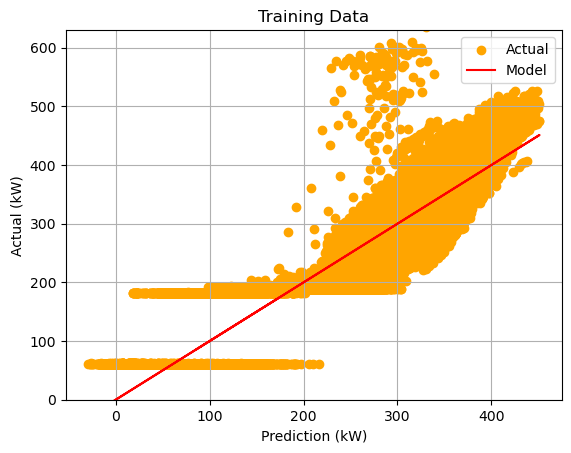

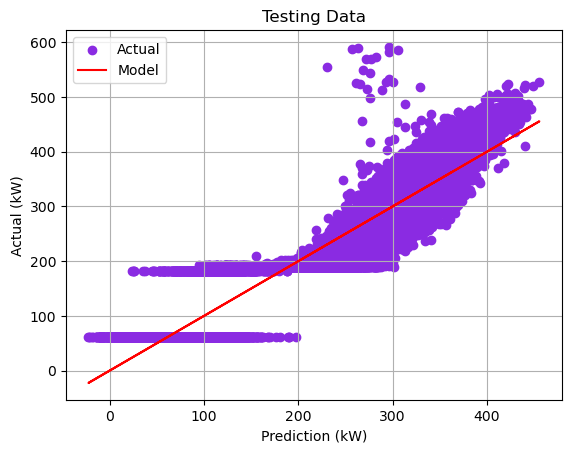

In [12]:
# Plot predicted train vs actual training data
fig,ax = plt.subplots()
ax.scatter(y_predict_train,y_train, c='orange', label='Actual')
ax.plot(y_predict_train, y_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()
ax.set_ylim([0, 630])

# Plot predicted test vs actual test data
fig,ax = plt.subplots()
ax.scatter(y_predict_test, y_test, c='blueviolet', label='Actual')
ax.plot(y_predict_test, y_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
ax.legend()
ax.grid()

In [13]:
# Error Evaluation 
# Training error 

print("Train Data")
print("R^2:", r2_score(y_train, y_predict_train))
print("MSE:", mean_squared_error(y_train, y_predict_train))
print("Root MSE:", np.sqrt(mean_squared_error(y_train, y_predict_train)))
print("MAE:", mean_absolute_error(y_train, y_predict_train))
print("MAPE: %", mean_absolute_percentage_error(y_train ,y_predict_train))

print(" ")

# Test Error
print("Test Data")
print("R^2:", r2_score(y_test, y_predict_test))
print("MSE:", mean_squared_error(y_test, y_predict_test))
print("Root MSE:", np.sqrt(mean_squared_error(y_test, y_predict_test)))
print("MAE:", mean_absolute_error(y_test, y_predict_test))
print("MAPE: %", mean_absolute_percentage_error(y_test, y_predict_test))

Train Data
R^2: 0.8787856614519317
MSE: 1560.5493039163644
Root MSE: 39.50378847549136
MAE: 31.073023629828313
MAPE: % 0.22538274596314245
 
Test Data
R^2: 0.88283963653581
MSE: 1520.7603606327095
Root MSE: 38.99692757939668
MAE: 30.82258339977069
MAPE: % 0.22216850076533476
